In [29]:
import requests
from typing import Any

url = "https://graphql.pokeapi.co/v1beta2"

query = """
query getPokemon {
  pokemon {
    id
    name
    pokemonspecy {
      is_baby
      is_legendary
      is_mythical
    }
	  pokemontypes(order_by: { slot: asc }) {
      type {
        name
      }
    }
    pokemonstats(order_by: { stat_id: asc }) {
      base_stat
      stat {
        name
      }
    }
  }
}
"""

variables = {}

payload: dict[str, Any] = {
    "query": query,
    "variables": variables,
}

res = requests.post(
    url,
    json=payload,
)

jsonData = res.json()
# res.content



In [30]:
import json

with open('./pokemon.json', 'w') as f:
	json.dump(jsonData, f)

In [32]:
pokemon_from_graphql = jsonData['data']['pokemon']

pokemon_from_graphql[100]

{'id': 101,
 'name': 'electrode',
 'pokemonspecy': {'is_baby': False,
  'is_legendary': False,
  'is_mythical': False},
 'pokemontypes': [{'type': {'name': 'electric'}}],
 'pokemonstats': [{'base_stat': 60, 'stat': {'name': 'hp'}},
  {'base_stat': 50, 'stat': {'name': 'attack'}},
  {'base_stat': 70, 'stat': {'name': 'defense'}},
  {'base_stat': 80, 'stat': {'name': 'special-attack'}},
  {'base_stat': 80, 'stat': {'name': 'special-defense'}},
  {'base_stat': 150, 'stat': {'name': 'speed'}}]}

In [66]:
import numpy as np

class Pokemon:
	name: str
	id: int

	# Stats
	hp: int = 0
	attack: int = 0
	defense: int = 0
	special_attack: int = 0
	special_defense: int = 0
	speed: int = 0

	# Metadata
	types: list[str] = []
	is_legendary: bool = False
	is_mythical: bool = False
	is_baby: bool = False
	is_variant_or_mega: bool = False

	def __init__(self, pokemon_from_graphql):
		self.id = pokemon_from_graphql['id']
		self.name = pokemon_from_graphql['name']
		stats = pokemon_from_graphql['pokemonstats']
		self.hp = next((stat for stat in stats if stat['stat']['name'] == 'hp'))['base_stat']
		self.attack = next((stat for stat in stats if stat['stat']['name'] == 'attack'))['base_stat']
		self.defense = next((stat for stat in stats if stat['stat']['name'] == 'defense'))['base_stat']
		self.special_attack = next((stat for stat in stats if stat['stat']['name'] == 'special-attack'))['base_stat']
		self.special_defense = next((stat for stat in stats if stat['stat']['name'] == 'special-defense'))['base_stat']
		self.speed = next((stat for stat in stats if stat['stat']['name'] == 'speed'))['base_stat']

		self.types = [t['type']['name'] for t in pokemon_from_graphql['pokemontypes']]
		self.is_legendary = pokemon_from_graphql['pokemonspecy']['is_legendary']
		self.is_mythical = pokemon_from_graphql['pokemonspecy']['is_mythical']
		self.is_baby = pokemon_from_graphql['pokemonspecy']['is_baby']
		self.is_variant_or_mega = self.id > 10000


	def __repr__(self):
		result = f"{self.name} ({self.id})\n==============\nHP: {self.hp}\nATK: {self.attack}\nDEF: {self.defense}\nSP_ATK: {self.special_attack}\nSP_DEF: {self.special_defense}\nSPD: {self.speed}\n\nTypes: {', '.join(self.types)}\n"
		if (self.is_legendary):
			result += '* Legendary'
		if (self.is_mythical):
			result += '* Mythical'
		if (self.is_baby):
			result += '* Baby'
		return result
	
	def stats(self):
		return np.array([self.hp, self.attack, self.defense, self.special_attack, self.special_defense, self.speed])
		

pokemon = [Pokemon(p) for p in pokemon_from_graphql]
pokemon[100]

	

electrode (101)
HP: 60
ATK: 50
DEF: 70
SP_ATK: 80
SP_DEF: 80
SPD: 150

Types: electric

In [67]:
import numpy as np

X = np.array([ [p.hp, p.attack, p.defense, p.special_attack, p.special_defense, p.speed] for p in pokemon]) 
means = X.mean(axis=0)
# n x 6
#     6

X_centered = X - means

X_centered.shape

(1350, 6)

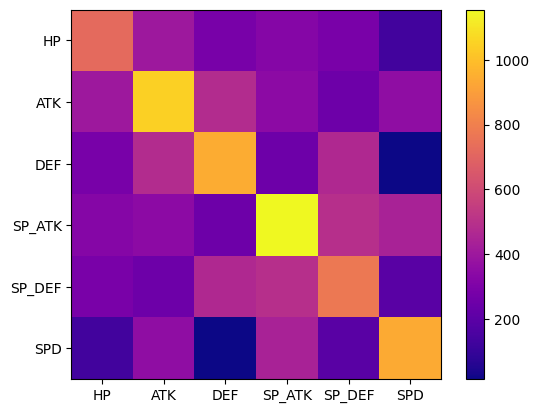

In [68]:
covariance = X_centered.T @ X_centered / (len(X_centered) - 1)
stats = ['HP', 'ATK', 'DEF', 'SP_ATK', 'SP_DEF', 'SPD'];

import matplotlib.pylab as plt

plt.imshow(covariance, cmap='plasma')
plt.xticks(range(covariance.shape[0]), stats)
plt.yticks(range(covariance.shape[1]), stats)
plt.colorbar()
plt.show()


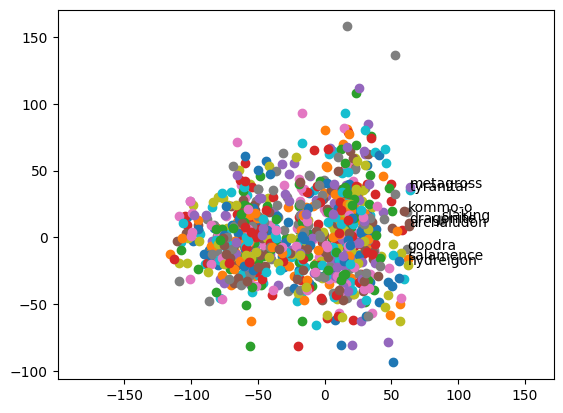

In [ ]:
eigenvalues, eigenvectors = np.linalg.eig(covariance)

primary_vectors = eigenvectors[:, :2] #6x2

compressed_stats = X_centered@primary_vectors
n_to_show = 1300
# plt.scatter(compressed_stats[:n_to_show, 0], compressed_stats[:n_to_show, 1])

for i in range(n_to_show):
	if not pokemon[i].is_variant_or_mega and not pokemon[i].is_legendary and not pokemon[i].is_mythical:
		plt.scatter(compressed_stats[i][0], compressed_stats[i][1])
		if (compressed_stats[i][0] > 60):
			plt.text(compressed_stats[i][0], compressed_stats[i][1], pokemon[i].name)
plt.axis('equal')
plt.show()

